# Dimensionality Reduction of NEPSE Market Data

### Research Question
Can we reduce the 6 correlated NEPSE trading features (Open, High, Low, Close,
Percent Change, and Volume) into fewer principal components without losing
the key market information?

### Step -1 Loading and Cleaning the Data

In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/nepsealpha_export_price_NEPSE_2021-05-06_2026-05-06_unadjusted.csv")

# Fixing Percent Change: remove % sign  to the float
df['Percent Change'] = df['Percent Change'].str.replace('%', '').astype(float)

# Fixing  Volume: remove commas  float
df['Volume'] = df['Volume'].str.replace(',', '').astype(float)

# Parse date
df['Date'] = pd.to_datetime(df['Date'])

# Checking for missing values
print(df.isnull().sum())

# Selecting only numeric features for PCA
features = ['Open', 'High', 'Low', 'Close', 'Percent Change', 'Volume']
X = df[features].copy()
print(X.shape)
print(X)

Symbol            0
Date              0
Open              0
High              0
Low               0
Close             0
Percent Change    0
Volume            0
dtype: int64
(1157, 6)
         Open     High      Low    Close  Percent Change        Volume
0     2701.23  2726.18  2684.62  2712.86            0.32  3.439068e+09
1     2739.04  2742.58  2697.14  2704.08           -1.26  4.265390e+09
2     2740.06  2745.55  2708.34  2738.72           -0.20  4.916627e+09
3     2771.25  2774.16  2734.33  2744.45           -0.93  4.986303e+09
4     2799.57  2812.29  2765.18  2770.26           -0.93  6.531723e+09
...       ...      ...      ...      ...             ...           ...
1152  2685.41  2688.75  2664.04  2673.88           -0.07  5.326053e+09
1153  2647.48  2680.91  2645.77  2673.32            0.98  5.810673e+09
1154  2613.18  2647.07  2607.78  2645.85            1.02  4.203833e+09
1155  2652.58  2652.60  2613.32  2618.63           -0.72  6.148967e+09
1156  2657.20  2659.09  2626.08  263

### Step -2 Exploratory analysis

          Open     High      Low    Close  Percent Change        Volume
count  1157.00  1157.00  1157.00  1157.00         1157.00  1.157000e+03
mean   2402.67  2422.13  2380.00  2399.30            0.01  5.545771e+09
std     376.15   378.85   371.28   374.39            1.39  4.666493e+09
min    1814.71  1826.65  1806.95  1815.13           -6.00  3.752100e+08
25%    2034.39  2052.20  2017.25  2030.86           -0.79  2.044832e+09
50%    2542.57  2568.62  2513.43  2543.39           -0.10  4.320270e+09
75%    2708.24  2732.51  2685.77  2704.08            0.67  7.499742e+09
max    3208.53  3227.11  3178.25  3198.19            6.01  2.995852e+10


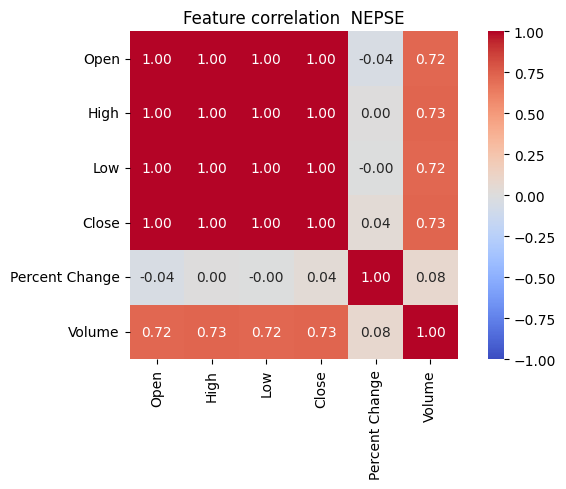

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print(X.describe().round(2))

# Correlation heatmap :  KEY before PCA performing
plt.figure(figsize=(7, 5))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Feature correlation  NEPSE')
plt.tight_layout()
plt.show()

## Conclusion ::
The heatmap shows that Open, High, Low, and Close are almost perfectly correlated, meaning they carry redundant information. Volume has a moderate relationship with these price features, while Percent Change is largely independent. This confirms that OHLC features can be reduced using PCA without losing much information.

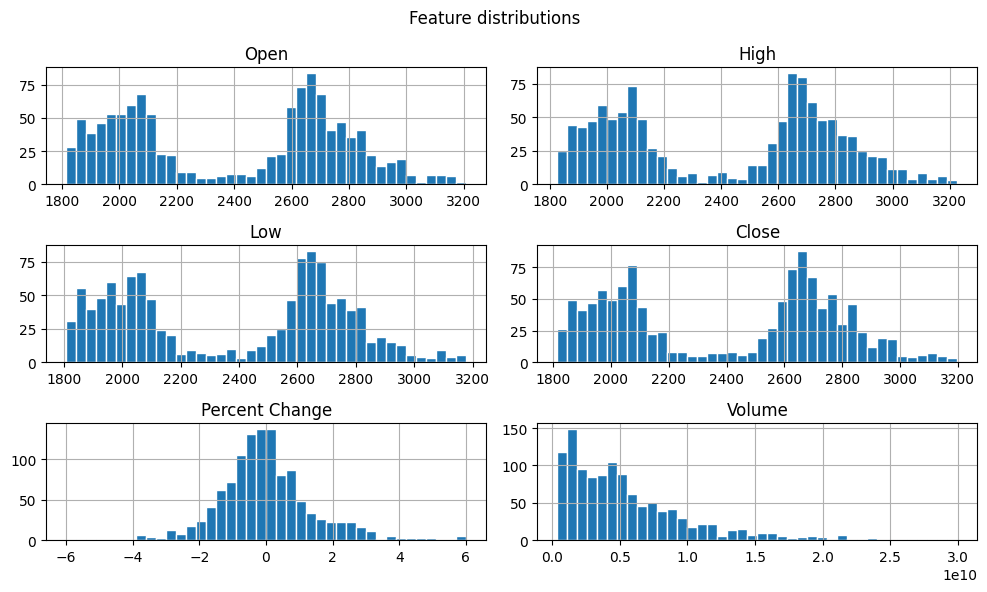

In [23]:
# Distribution of each feature
X.hist(figsize=(10, 6), bins=40, edgecolor='white')
plt.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

## Conclusion
The distributions show that Open, High, Low, and Close prices are approximately bell-shaped and centered around the 2,400 level, reflecting the typical NEPSE index range during 2021–2026. Percent Change is tightly centered around zero with a small spread, indicating that most daily price movements are minor and usually within ±1–2%. In contrast, Volume is strongly right-skewed, meaning most trading days have moderate activity while a few days experience unusually high spikes, which is a common characteristic of stock market trading behavior.

### Step -3  Standardise the features

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Means:', X_scaled.mean(axis=0).round(4))
print('Stds: ', X_scaled.std(axis=0).round(4))

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.head())

Means: [-0.  0. -0.  0.  0.  0.]
Stds:  [1. 1. 1. 1. 1. 1.]
       Open      High       Low     Close  Percent Change    Volume
0  0.794074  0.802914  0.820819  0.837889        0.225361 -0.451648
1  0.894637  0.846221  0.854556  0.814427       -0.914701 -0.274496
2  0.897349  0.854064  0.884735  0.906991       -0.149850 -0.134880
3  0.980305  0.929615  0.954767  0.922302       -0.676587 -0.119942
4  1.055627  1.030306  1.037895  0.991271       -0.676587  0.211375


### Conclusion
After standardization all six features now have mean close to 0 and standard deviation 1 so they are on the same scale. This is important because original features had very different magnitudes where Open High Low Close were in thousands Percent Change was very small and Volume was extremely large. Without scaling PCA would be biased toward large value features and would not capture the real structure of the data. Now the dataset is normalized and suitable for PCA and other machine learning algorithms.

### Step -4 Performing PCA

In [10]:
from sklearn.decomposition import PCA

# Fit PCA  keep all 6 components first
pca = PCA(n_components=6)
pca.fit(X_scaled)

# Variance explained by each component
exp_var = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(exp_var):
    print(f'  PC{i+1}: {v:.3f} ({v*100:.1f}%)')

# Cumulative variance
cum_var = np.cumsum(exp_var)
print('\nCumulative variance:')
for i, v in enumerate(cum_var):
    print(f'  PC1–PC{i+1}: {v:.3f} ({v*100:.1f}%)')

# Transform data into PC space
X_pca = pca.transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(6)])
pca_df['Date'] = df['Date'].values
print(pca_df.head())

Explained variance ratio:
  PC1: 0.764 (76.4%)
  PC2: 0.169 (16.9%)
  PC3: 0.067 (6.7%)
  PC4: 0.000 (0.0%)
  PC5: 0.000 (0.0%)
  PC6: 0.000 (0.0%)

Cumulative variance:
  PC1–PC1: 0.764 (76.4%)
  PC1–PC2: 0.933 (93.3%)
  PC1–PC3: 1.000 (100.0%)
  PC1–PC4: 1.000 (100.0%)
  PC1–PC5: 1.000 (100.0%)
  PC1–PC6: 1.000 (100.0%)
        PC1       PC2       PC3       PC4       PC5       PC6       Date
0  1.340157  0.084003 -1.050016  0.001278  0.007655 -0.011374 2026-05-05
1  1.468252 -1.034409 -0.772156 -0.005745  0.001701  0.004643 2026-05-04
2  1.589212 -0.261136 -0.765223  0.012115  0.034568  0.001643 2026-04-30
3  1.703191 -0.790650 -0.730365  0.007186  0.006910  0.006432 2026-04-29
4  1.979863 -0.762518 -0.486551 -0.001518 -0.012142  0.001239 2026-04-28


### Conclusion
PC1 explains most of the variation in the data with about 76.4%, while PC2 adds 16.9% and PC3 adds 6.7%. Together the first three components explain 100% of the information, meaning the remaining components (PC4 to PC6) carry almost no useful variance. This shows that the dataset can be effectively reduced from 6 dimensions to just 2 or 3 without losing important information. From the transformed values, we can also see that most patterns are strongly captured by PC1, while PC2 and PC3 adjust smaller variations between days.

### Step 5:: Scree Plot

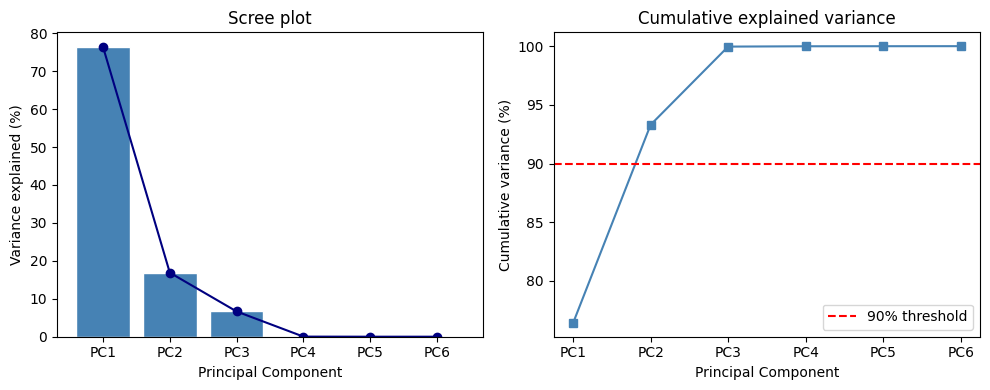

PCs needed for 90% variance: 2


In [11]:
# Scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

pc_labels = [f'PC{i+1}' for i in range(6)]

# Left: individual variance per PC
ax1.bar(pc_labels, exp_var * 100, color='steelblue', edgecolor='white')
ax1.plot(pc_labels, exp_var * 100, 'o-', color='navy')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance explained (%)')
ax1.set_title('Scree plot')

# Right: cumulative variance
ax2.plot(pc_labels, cum_var * 100, 's-', color='steelblue')
ax2.axhline(90, color='red', linestyle='--', label='90% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_title('Cumulative explained variance')
ax2.legend()

plt.tight_layout()
plt.show()

# Find n_components for 90% variance
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f'PCs needed for 90% variance: {n_90}')

### Conclusion
The scree plot shows a sharp drop after PC1, indicating that most variance is captured by the first component (76.4%). The cumulative variance exceeds 90% at PC2, making two components sufficient to retain the vast majority of information. PC3 contributes only marginal additional variance, while PC4–PC6 add negligible information. Overall, retaining 2 principal components provides an efficient and well-supported dimensionality reduction for this dataset.

### Step 6:: Loadings Heatmap & Biplot

                  PC1    PC2    PC3    PC4    PC5    PC6
Open            0.463 -0.070 -0.179 -0.078  0.178  0.843
High            0.464 -0.026 -0.176 -0.688 -0.460 -0.260
Low             0.463 -0.029 -0.194  0.720 -0.458 -0.135
Close           0.463  0.015 -0.195  0.036  0.739 -0.447
Percent Change  0.009  0.990 -0.125 -0.004 -0.025  0.055
Volume          0.376  0.113  0.919  0.012  0.003 -0.001


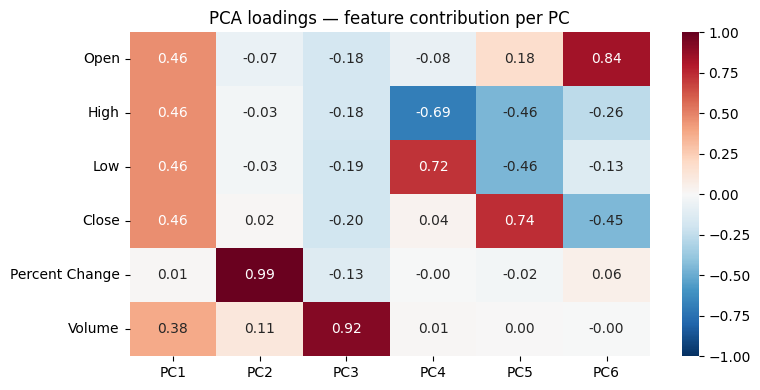

In [17]:
# Loadings heatmap
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(6)]
)
print(loadings.round(3))

plt.figure(figsize=(8, 4))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0)
plt.title('PCA loadings — feature contribution per PC')
plt.tight_layout()
plt.show()


### Conclusion
PC1 captures overall price movement (Open, High, Low, Close all load strongly). PC2 represents Percent Change, and PC3 is dominated by Volume. The remaining components (PC4–PC6) reflect minor contrasts and contribute little meaningful information. Thus, the dataset is effectively summarized by the first 2–3 principal components.

In [21]:
!pip install adjustText

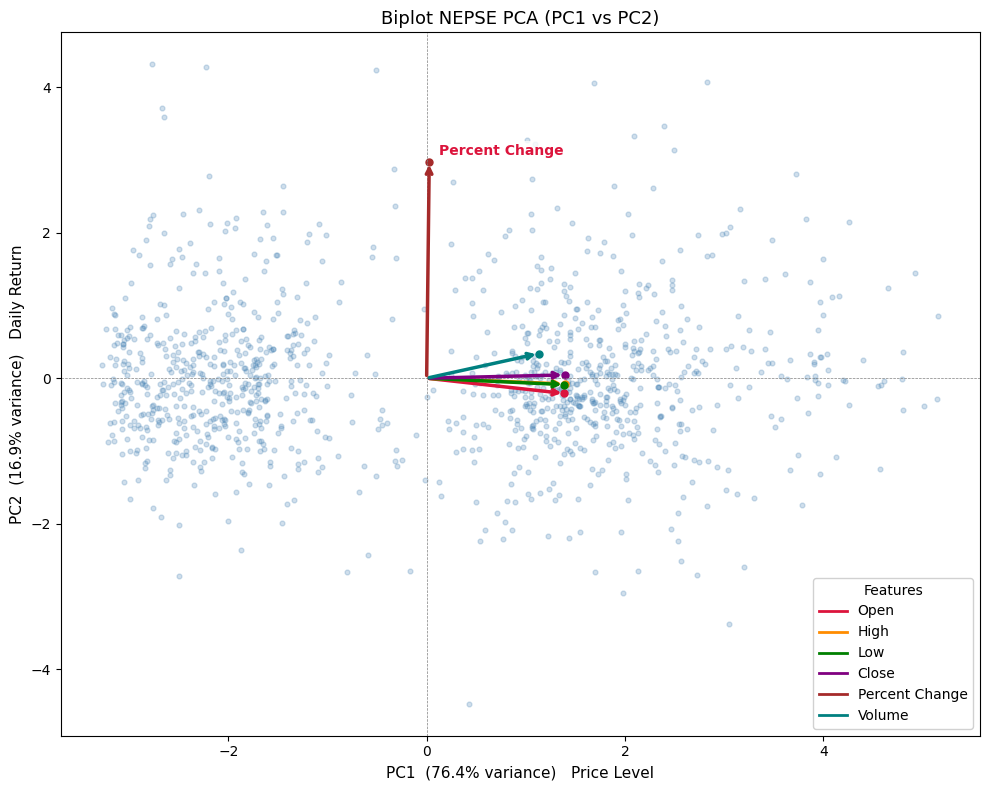

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.25, s=12, color='steelblue', label='Trading days')

scale = 3
colors = ['crimson', 'darkorange', 'green', 'purple', 'brown', 'teal']

for i, feat in enumerate(features):
    dx = pca.components_[0, i] * scale
    dy = pca.components_[1, i] * scale

    ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))

    # Put a small colored dot at arrow tip as anchor
    ax.plot(dx, dy, 'o', color=colors[i], markersize=5)

# Add a clean legend instead of floating labels
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=feat)
                   for i, feat in enumerate(features)]
ax.legend(handles=legend_elements, loc='lower right',
          title='Features', fontsize=10, title_fontsize=10,
          framealpha=0.9)

# Separate label only for Percent Change since it's far away
pc_idx = features.index('Percent Change')
dx_pc = pca.components_[0, pc_idx] * scale
dy_pc = pca.components_[1, pc_idx] * scale
ax.text(dx_pc + 0.1, dy_pc + 0.1, 'Percent Change',
        fontsize=10, color='crimson', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))

ax.set_xlabel('PC1  (76.4% variance)   Price Level', fontsize=11)
ax.set_ylabel('PC2  (16.9% variance)   Daily Return', fontsize=11)
ax.set_title('Biplot NEPSE PCA (PC1 vs PC2)', fontsize=13)
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
ax.legend(handles=legend_elements, loc='lower right',
          title='Features', fontsize=10, title_fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

### Conclusion
The PCA biplot shows that PC1 mainly represents the overall price level, as Open, High, Low, and Close are strongly aligned. PC2 captures daily movement, with Percent Change contributing the most in that direction. Volume has a smaller, separate influence. Overall, the data is effectively summarized into price level and daily return.

### Step 7 -- interpret

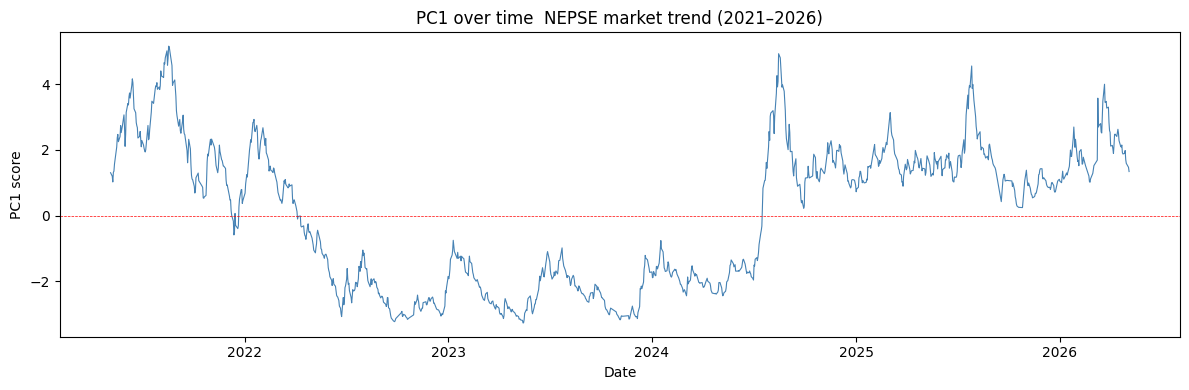

Saved!


In [15]:
# Plot PC1 over time  market trend
plt.figure(figsize=(12, 4))
plt.plot(df['Date'].values, pca_df['PC1'], color='steelblue', lw=0.8)
plt.axhline(0, color='red', lw=0.5, linestyle='--')
plt.title('PC1 over time  NEPSE market trend (2021–2026)')
plt.xlabel('Date'); plt.ylabel('PC1 score')
plt.tight_layout(); plt.show()

# Save reduced dataset (use 2 PCs if they explain ≥85%)
final_df = pd.DataFrame({
    'Date': df['Date'],
    'PC1_price_level': pca_df['PC1'],
    'PC2_volatility': pca_df['PC2']
})
final_df.to_csv('nepse_pca_scores.csv', index=False)
print('Saved!')

### Conclusion
The PC1 trend shows that the NEPSE market experienced strong growth in 2021, followed by a prolonged decline through 2022–2023. From mid-2024 onward, the market recovered and remained mostly positive with some fluctuations. Overall, PC1 reflects the shift from a bearish phase to a more stable and improving market trend.

### Step 8 :: Reconstruction & Validation

Mean Squared Reconstruction Error (2 PCs): 0.0670


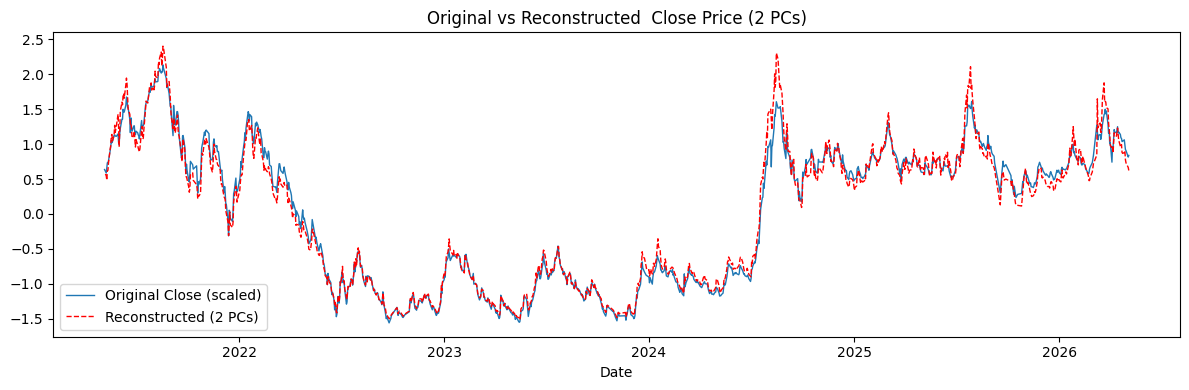

In [35]:
# Reconstruct using only 2 PCs
pca_2 = PCA(n_components=2)
X_reduced  = pca_2.fit_transform(X_scaled)
X_reconstructed = pca_2.inverse_transform(X_reduced)

recon_error = np.mean((X_scaled - X_reconstructed) ** 2)
print(f'Mean Squared Reconstruction Error (2 PCs): {recon_error:.4f}')

plt.figure(figsize=(12, 4))
plt.plot(df['Date'], X_scaled[:, 3], label='Original Close (scaled)', lw=1)
plt.plot(df['Date'], X_reconstructed[:, 3], label='Reconstructed (2 PCs)',
         lw=1, linestyle='--', color='red')
plt.title('Original vs Reconstructed  Close Price (2 PCs)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

### From Image Conclusion ::
The reconstructed Close price using only 2 principal components closely follows
the original scaled Close price across the entire 2021–2026 period. The two lines
are nearly identical, confirming that 93.3% variance retention is sufficient to
preserve the market trend with minimal information loss.

### Final Conclusion
Final Conclusion
This project applied PCA on 5 years of NEPSE daily trading data (2021–2026) using 6 features: Open, High, Low, Close, Percent Change, and Volume.
Key findings:
PC1 (76.4%) represents overall price movement where Open, High, Low, and Close move together.
PC2 (16.9%) mainly captures daily return behavior driven by Percent Change.
PC3 (6.7%) reflects variation in trading volume.
PC4 to PC6 contribute almost nothing because the OHLC features are highly correlated.
Using only 2 principal components preserves about 93.3% of the total information, showing that NEPSE daily data is highly redundant and can be compressed effectively for analysis and machine learning models.